# Implementação da Arquitetura LeNet-5 em PyTorch
Com função de ativação ReLU e Max Pooling.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torchvision

class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        # C1: Camada convolucional (1 canal de entrada, 6 canais de saída, kernel 5x5)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5)
        
        # S2: Camada de subamostragem (Max Pooling 2x2)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # C3: Camada convolucional (6 canais de entrada, 16 canais de saída, kernel 5x5)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)
        
        # S4: Camada de subamostragem (Max Pooling 2x2)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # C5: Camada totalmente conectada (16 * 4 * 4 = 256 entradas para MNIST 28x28, 120 saídas)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        
        # F6: Camada totalmente conectada (120 entradas, 84 saídas)
        self.fc2 = nn.Linear(120, 84)
        
        # Output: Camada de saída (84 entradas, 10 saídas - classes)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        # Passando pelas camadas convolucionais com função de ativação ReLU
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        
        # Achatamento (flatten) do tensor para a próxima camada totalmente conectada
        x = torch.flatten(x, 1) 
        
        # Passando pelas camadas totalmente conectadas com ReLU
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        
        # Camada de saída
        x = self.fc3(x)
        return x


### Exibição dos Filtros da Primeira Camada Convolucional (Antes do Treinamento)

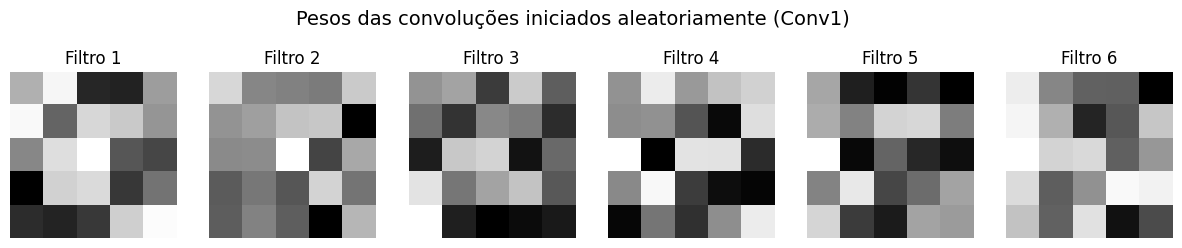

In [ ]:
# Inicializa o modelo
model = LeNet5()

# Obtêm os pesos do primeiro layer de convolução (conv1)
filters = model.conv1.weight.detach().clone()

# Prepara a visualização dos 6 filtros do canal de entrada (1x5x5)
fig, axes = plt.subplots(1, 6, figsize=(15, 3))

for i in range(6):
    # Extrai o filtro 'i' que pertence ao nosso único canal de entrada
    f = filters[i, 0]
    axes[i].imshow(f.numpy(), cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f'Filtro {i+1}')

plt.suptitle('Pesos das convoluções iniciados aleatoriamente (Conv1)', fontsize=14)
plt.show()


### Importando e Visualizando o Dataset MNIST

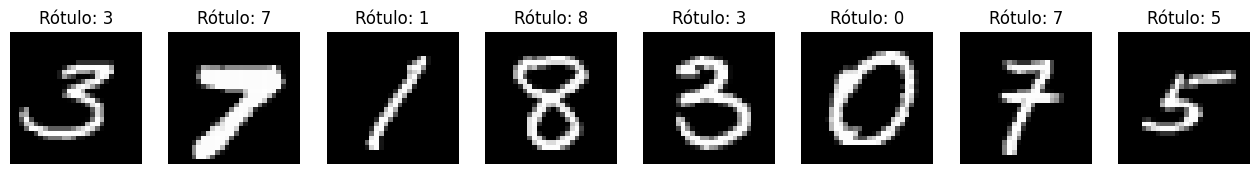

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Transformação para converter os dados MNIST em tensores adequados ao PyTorch
transform = transforms.Compose([
    transforms.ToTensor()
])

# Baixando e carregando o conjunto de dados de treinamento em './data'
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Criação de um DataLoader, para extrairmos imagens em lotes (ex: 8 imagens)
train_loader = DataLoader(dataset=train_dataset, batch_size=8, shuffle=True)

# Obtendo o primeiro lote de imagens usando um iterador
images, labels = next(iter(train_loader))

# Visualizando o lote de 8 imagens
fig, axes = plt.subplots(1, 8, figsize=(16, 2))

for i in range(8):
    # A dimensão do tensor é (1, 28, 28) por ter 1 canal. 
    # 'squeeze()' remove esse 1 para restar (28, 28), adequado para o Matplotlib
    axes[i].imshow(images[i].squeeze(), cmap='gray')
    axes[i].set_title(f'Rótulo: {labels[i].item()}')
    axes[i].axis('off')

plt.show()


### Treinamento da Rede
Nesta seção, definimos a função de perda (Loss), o otimizador e o loop de treinamento para treinar a LeNet-5 no dataset MNIST.

In [ ]:
import torch.optim as optim

# Verifica se há GPU disponível
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Treinando em: {device}")

# Move o modelo para o dispositivo
model = LeNet5().to(device)

# Definir função de perda e otimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Loop de Treinamento com acompanhamento de performance
num_epochs = 5
train_losses = []
train_accs = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        if (i+1) % 1000 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Passo [{i+1}/{len(train_loader)}], Loss: {running_loss/1000:.4f}')
            running_loss = 0.0
            
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    print(f'--- Fim da Epoch {epoch+1} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}% ---')

print("Treinamento concluído!")


Treinando em: cpu


Epoch [1/5], Passo [1000/7500], Loss: 0.4841


Epoch [1/5], Passo [2000/7500], Loss: 0.1571


Epoch [1/5], Passo [3000/7500], Loss: 0.1157


Epoch [1/5], Passo [4000/7500], Loss: 0.1071


...

Epoch [5/5], Passo [4000/7500], Loss: 0.0360


Epoch [5/5], Passo [5000/7500], Loss: 0.0318


Epoch [5/5], Passo [6000/7500], Loss: 0.0331


Epoch [5/5], Passo [7000/7500], Loss: 0.0349


--- Fim da Epoch 5 | Loss: 0.0024 | Acc: 99.01% ---
Treinamento concluído!


### Evolução da Performance
Visualização das curvas de perda e acurácia durante o treinamento.

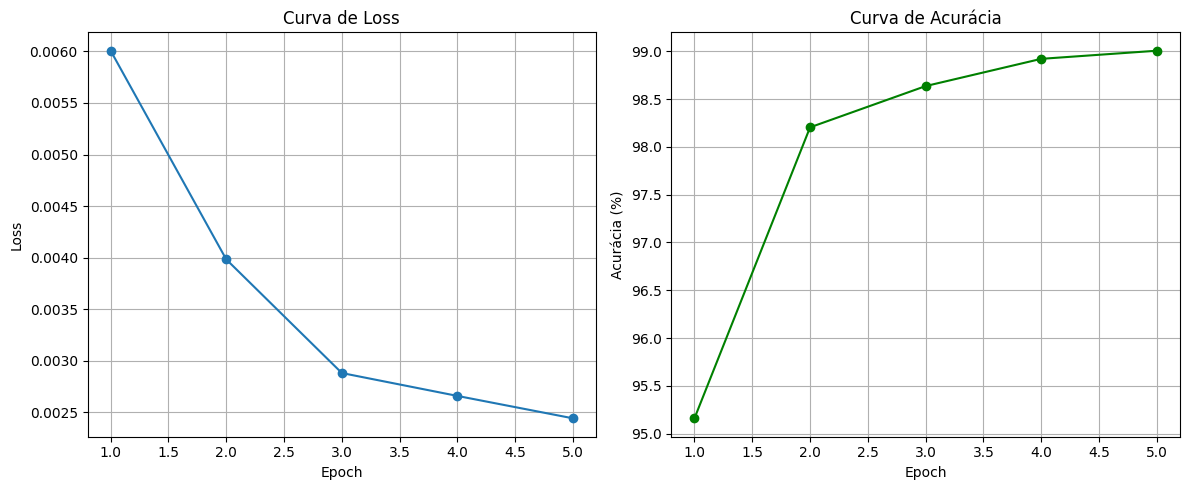

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, marker='o', label='Train Loss')
plt.title('Curva de Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_accs, marker='o', color='green', label='Train Acc')
plt.title('Curva de Acurácia')
plt.xlabel('Epoch')
plt.ylabel('Acurácia (%)')
plt.grid(True)

plt.tight_layout()
plt.show()


### Avaliação Final no Conjunto de Teste

In [ ]:
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Acurácia final no Teste: {100 * correct / total:.2f}%')


Acurácia final no Teste: 98.91%


### Salvando o Modelo
Por fim, vamos salvar os pesos treinados do modelo para que possamos carregá-los futuramente sem precisar treinar novamente.

In [ ]:
# Salva apenas os pesos (recomendado)
model_path = 'lenet5_mnist.pth'
torch.save(model.state_dict(), model_path)
print(f'Modelo salvo com sucesso em: {model_path}')

# Exemplo de como carregar futuramente:
# model = LeNet5()
# model.load_state_dict(torch.load('lenet5_mnist.pth'))
# model.eval()


Modelo salvo com sucesso em: lenet5_mnist.pth


### Análise de Erros (Misclassifications)
É importante entender onde o modelo está errando. Abaixo, filtramos o conjunto de teste para exibir apenas as imagens que a rede classificou incorretamente.

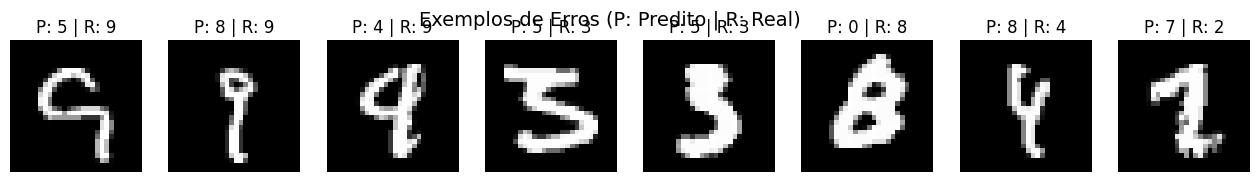

In [ ]:
model.eval()
misclassified_images = []
misclassified_labels = []
correct_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        # Filtra os índices onde houve erro
        errors = (predicted != labels)
        if errors.any():
            misclassified_images.append(images[errors].cpu())
            misclassified_labels.append(predicted[errors].cpu())
            correct_labels.append(labels[errors].cpu())
            
        # Para não carregar todos os erros se forem muitos (limite de 32 imagens)
        if sum([x.size(0) for x in misclassified_images]) > 32:
            break

# Concatena os resultados
mis_imgs = torch.cat(misclassified_images)
mis_preds = torch.cat(misclassified_labels)
mis_reals = torch.cat(correct_labels)

# Plotagem de alguns erros
num_errors_to_show = min(len(mis_imgs), 8)
fig, axes = plt.subplots(1, num_errors_to_show, figsize=(16, 2))
for i in range(num_errors_to_show):
    axes[i].imshow(mis_imgs[i].squeeze(), cmap='gray')
    axes[i].set_title(f'P: {mis_preds[i]} | R: {mis_reals[i]}')
    axes[i].axis('off')
plt.suptitle('Exemplos de Erros (P: Predito | R: Real)', fontsize=14)
plt.show()


### Carregando o Modelo
Aqui demonstramos como carregar os pesos salvos anteriormente para utilizar o modelo sem necessidade de novo treinamento.

In [ ]:
# 1. Instanciar a arquitetura
loaded_model = LeNet5().to(device)

# 2. Carregar os pesos salvos
model_path = 'lenet5_mnist.pth'
loaded_model.load_state_dict(torch.load(model_path, map_location=device))

# 3. Mudar para modo de avaliação
loaded_model.eval()
print(f"Modelo carregado com sucesso de: {model_path}")

# 4. Teste rápido com uma imagem do dataset de teste
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
output = loaded_model(images[0].unsqueeze(0))
_, pred = torch.max(output, 1)

print(f"Predição do modelo carregado: {pred.item()} | Rótulo Real: {labels[0].item()}")


Modelo carregado com sucesso de: lenet5_mnist.pth
Predição do modelo carregado: 7 | Rótulo Real: 7


### Visualização dos Mapas de Características (Primeira Camada)
Para entender o que a rede aprende, vamos visualizar a saída da primeira camada convolucional (`conv1`) após a aplicação da ativação ReLU. Isso nos mostra os padrões (bordas, curvas) que a rede está detectando em uma imagem específica.

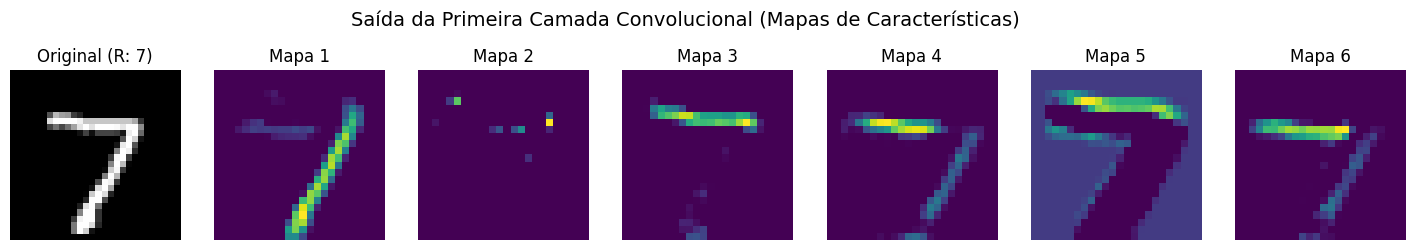

In [ ]:
# 1. Selecionar uma imagem de exemplo do test_loader
data_iter = iter(test_loader)
images, labels = next(data_iter)
sample_image = images[0].unsqueeze(0).to(device) # Pega a primeira imagem e move para o dispositivo

# 2. Passar a imagem pela primeira camada convolucional e ReLU
with torch.no_grad():
    feature_maps = F.relu(model.conv1(sample_image))

# 3. Visualizar a imagem original e os 6 mapas de características resultantes
fig, axes = plt.subplots(1, 7, figsize=(18, 3))

# Imagem Original
axes[0].imshow(sample_image.cpu().squeeze(), cmap='gray')
axes[0].set_title(f'Original (R: {labels[0].item()})')
axes[0].axis('off')

# Mapas de Características (6 canais de saída da conv1)
for i in range(6):
    f_map = feature_maps[0, i].cpu().numpy()
    axes[i+1].imshow(f_map, cmap='viridis') # Usando viridis para destacar as ativações
    axes[i+1].set_title(f'Mapa {i+1}')
    axes[i+1].axis('off')

plt.suptitle('Saída da Primeira Camada Convolucional (Mapas de Características)', fontsize=14)
plt.show()
